# Volterra Moving-Average Models: Sample Paths and Higher-Order Spectral Analysis

This notebook accompanies **"Constructing a Nonlinear (Volterra) Moving-Average Representation"**.  
It constructs univariate examples of the three canonical subclasses from Section 4 of that note—  
**Hammerstein**, **Wiener cascade**, and **bilinear**—generates sample paths, and uses  
the [`higher-spectrum`](https://pypi.org/project/higher-spectrum/) package to compute  
bispectra and bicoherence for each.

The central question is: *when and how does higher-order spectral analysis reveal nonlinear structure  
that the ordinary (second-order) power spectrum cannot?*

---

**Recall the three models** (all driven by iid $\varepsilon_t \sim \mathcal{N}(0,1)$):

| Model | Structure | Second-order kernel $H_2(\omega_1,\omega_2)$ |
|-------|-----------|----------------------------------------------|
| Hammerstein | nonlinearity **then** linear filter | $c_2\,\Psi(\omega_1+\omega_2)$ — depends only on **sum frequency** |
| Wiener cascade | linear filter **then** nonlinearity | $c_2\,\Psi(\omega_1)\Psi(\omega_2)$ — **separable** product |
| Bilinear | feedback cross-product | infinite-order Volterra; richer, non-separable pattern |

These three structures generate identical (or very similar) second-order power spectra but  
leave distinct fingerprints in the **bispectrum** $B(\omega_1,\omega_2)$ and  
**bicoherence** $b(\omega_1,\omega_2)$.

---

> **Companion to the theory chapter.** This lab accompanies [*Nonlinear (Volterra) Moving-Average Representations*](39_nonlinear_representation.md). It constructs the three canonical model classes of that chapter (**Hammerstein**, **Wiener cascade**, **bilinear**), simulates sample paths, and computes their **bispectra** and **bicoherence** to show how higher-order spectra reveal nonlinear structure invisible to the ordinary power spectrum. The bispectral estimators are the self-contained NumPy implementations in `code/higher_spectra.py` (no external `higher-spectrum` dependency).


## 1. Import Libraries and Setup

We use **AR(2) dynamics** with poles at $r e^{\pm i\omega_0}$ (modulus $r=0.894$, peak frequency $f_0\approx0.133$ cycles/sample) as the shared linear filter $\Psi$.  This choice puts the spectral peak away from DC, which makes the bispectral patterns visually distinct and theoretically interpretable.

**Key parameter choices:**
- $\phi_1 = 1.2$, $\phi_2 = -0.8$  →  AR(2) spectral peak at $f_0\approx0.133$ cycles/sample  
- $c_2 = 0.5$  →  moderate quadratic nonlinearity  
- $c_{\rm bl} = 0.3$  →  bilinear coupling coefficient (stability checked below)

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import lfilter, welch

# Self-contained higher-order spectral estimators (replaces the external
# `higher-spectrum` package). Locate code/ regardless of the working directory.
_HERE = os.getcwd()
for _p in (os.path.join(_HERE, '..', 'code'), os.path.join(_HERE, 'code'),
           os.path.join(_HERE, 'time_series_myst', 'code')):
    if os.path.isdir(_p) and _p not in sys.path:
        sys.path.insert(0, _p)
from higher_spectra import bispectrumd, bicoherence, acf_np

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

# ── Reproducibility ──────────────────────────────────────────────────────────
np.random.seed(42)

# ── Simulation parameters ─────────────────────────────────────────────────────
N   = 8192       # sample size

# AR(2) linear filter (shared across Hammerstein and Wiener cascade)
phi1, phi2 = 1.2, -0.8
# Poles at r*exp(±i*omega0):
r_pole  = np.sqrt(-phi2)               # ≈ 0.894
omega0  = np.arccos(phi1 / (2*r_pole)) # ≈ 0.836 rad/sample
f0      = omega0 / (2*np.pi)           # ≈ 0.133 cycles/sample

# Theoretical variance of AR(2)(phi1,phi2) with unit-variance innovations
rho1     = phi1 / (1 - phi2)
rho2     = phi1*rho1 + phi2
sigma_u2 = 1.0 / (1 - phi1*rho1 - phi2*rho2)   # = 5.0

# Nonlinearity parameters
c2   = 0.5    # quadratic coefficient  g(u) = u + c2*(u^2 - mean)
c_bl = 0.3    # bilinear coupling:     stability requires phi1^2+phi2^2+c_bl^2*sigma < 1 (checked below)

# Bispectrum estimation parameters
# NOTE: nfft must be >= nsamp to avoid a known bug in higher-spectrum's nextpow2
NSAMP   = 256   # segment length → frequency resolution 1/256 ≈ 0.004 cycles/sample
NFFT    = 256   # FFT length (must be ≥ NSAMP)
OVERLAP = 50    # % overlap between segments

# Generate the shared innovation sequence
eps = np.random.randn(N)

print(f"AR(2) pole modulus  r  = {r_pole:.4f}")
print(f"AR(2) peak frequency f0 = {f0:.4f}  cycles/sample  "
      f"(omega0 = {omega0:.4f} rad/sample)")
print(f"AR(2) stationary variance sigma_u^2 = {sigma_u2:.4f}")
print(f"Bilinear stability proxy  phi1^2+phi2^2+c_bl^2 = "
      f"{phi1**2 + phi2**2 + c_bl**2:.4f}  (< 1 required for AR(2) analogue)")

AR(2) pole modulus  r  = 0.8944
AR(2) peak frequency f0 = 0.1330  cycles/sample  (omega0 = 0.8355 rad/sample)
AR(2) stationary variance sigma_u^2 = 5.0000
Bilinear stability proxy  phi1^2+phi2^2+c_bl^2 = 2.1700  (< 1 required for AR(2) analogue)


## 2. Hammerstein Model — Sample Path Generation

The **Hammerstein** model applies a static nonlinearity to the innovations *before* passing them through a linear filter:

$$u_t = g(\varepsilon_t) = \varepsilon_t + c_2(\varepsilon_t^2 - 1), \qquad x_t = \phi_1 x_{t-1} + \phi_2 x_{t-2} + u_t.$$

The input $u_t$ is **white** (uncorrelated across time, since $\varepsilon_t$ are iid) but **non-Gaussian**: it has non-zero third cumulant $\kappa_3^{(u)} = 6c_2 + 8c_2^3$ for Gaussian $\varepsilon_t$.

**Volterra kernel structure:**  
The second-order kernel is *diagonal*: $h_2(j_1,j_2) = c_2\,\psi_{j_1}\,\delta_{j_1=j_2}$, where $\psi_j$ is the AR impulse response.  In the frequency domain:

$$H_2(\omega_1,\omega_2) = c_2\,\Psi(\omega_1+\omega_2).$$

The bispectrum depends only on the **sum frequency** $\omega_1+\omega_2$, so it is elevated along lines $\omega_1+\omega_2 = \pm f_0$ (and integer multiples).

**Power spectrum:**  Since $u_t$ is white with variance $\sigma_u^2 = 1+2c_2^2$, the power spectrum of $x_t$ is just a scaled AR(2) spectrum: $S_x(f) = (1+2c_2^2)\,|\Psi(f)|^2$.  The Hammerstein model does *not* generate harmonics in the power spectrum.

u_h: mean=0.0031, std=1.2426  (expected std = sqrt(1+2*c2^2) = 1.2247)
u_h 3rd cumulant ≈ 4.3195  (theoretical = 4.0000)


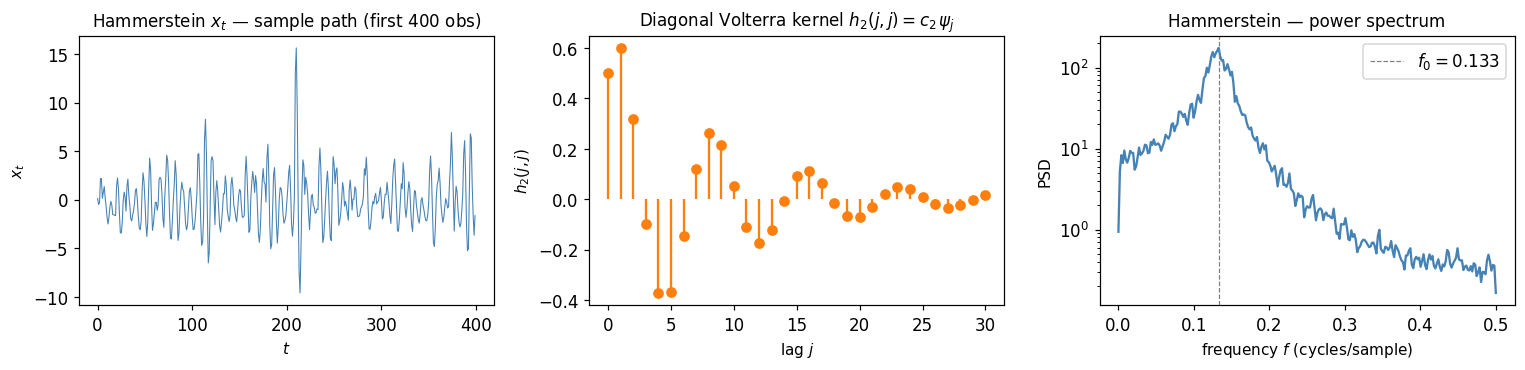


Hammerstein x_h: mean=0.0054, std=2.7935


In [2]:
# ── Hammerstein simulation ────────────────────────────────────────────────────
# Step 1: apply nonlinearity to iid innovations
#   g(eps) = eps + c2*(eps^2 - 1)   [centred so E[u_t] = 0]
u_h = eps + c2 * (eps**2 - 1.0)
print(f"u_h: mean={u_h.mean():.4f}, std={u_h.std():.4f}  "
      f"(expected std = sqrt(1+2*c2^2) = {np.sqrt(1+2*c2**2):.4f})")
print(f"u_h 3rd cumulant ≈ {np.mean(u_h**3):.4f}  "
      f"(theoretical = {6*c2 + 8*c2**3:.4f})")

# Step 2: pass through the AR(2) linear filter
x_h = lfilter([1.0], [1.0, -phi1, -phi2], u_h)

# ── Diagonal Volterra kernel illustration ────────────────────────────────────
# The impulse response of the AR(2) filter:  h1(j) = psi_j
J = 30
psi = lfilter([1.0], [1.0, -phi1, -phi2], np.eye(J+1)[0])  # delta-function input

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].plot(x_h[:400], lw=0.7, color="steelblue")
axes[0].set_title("Hammerstein $x_t$ — sample path (first 400 obs)")
axes[0].set_xlabel("$t$");  axes[0].set_ylabel("$x_t$")

# Diagonal Volterra kernel h2(j,j) = c2 * psi_j  (off-diagonal = 0)
j_vals = np.arange(J+1)
axes[1].stem(j_vals, c2 * psi[:J+1], basefmt=" ", markerfmt="C1o", linefmt="C1-")
axes[1].set_title("Diagonal Volterra kernel $h_2(j,j) = c_2\\,\\psi_j$")
axes[1].set_xlabel("lag $j$");  axes[1].set_ylabel("$h_2(j,j)$")

f_psd, psd_h = welch(x_h, fs=1.0, nperseg=512)
axes[2].semilogy(f_psd, psd_h, color="steelblue")
axes[2].axvline(f0, ls="--", color="gray", lw=0.8, label=f"$f_0={f0:.3f}$")
axes[2].set_title("Hammerstein — power spectrum")
axes[2].set_xlabel("frequency $f$ (cycles/sample)");  axes[2].set_ylabel("PSD")
axes[2].legend()

plt.tight_layout()
plt.show()
print(f"\nHammerstein x_h: mean={x_h.mean():.4f}, std={x_h.std():.4f}")

## 3. Wiener Cascade Model — Sample Path Generation

The **Wiener cascade** applies the linear filter *first*, then the nonlinearity:

$$u_t = \phi_1 u_{t-1} + \phi_2 u_{t-2} + \varepsilon_t, \qquad x_t = g(u_t) = u_t + c_2(u_t^2 - \sigma_u^2).$$

Here $u_t$ is a **Gaussian** AR(2) process (variance $\sigma_u^2 = 5$), and the nonlinearity is centred ($E[x_t]=0$).

**Volterra kernel structure:**  
$h_2(j_1,j_2) = c_2\,\psi_{j_1}\psi_{j_2}$ — **separable** (rank-1 outer product).  In the frequency domain:

$$H_2(\omega_1,\omega_2) = c_2\,\Psi(\omega_1)\Psi(\omega_2).$$

The bispectrum is elevated wherever **both** $\omega_1$ and $\omega_2$ lie near the spectral peak $f_0$ — producing point masses rather than ridges.

**Power spectrum:**

$$S_x(f) = |\Psi(f)|^2 + 2c_2^2\,(S_u * S_u)(f)/(2\pi),$$

where $*$ is convolution.  The self-convolution term generates **harmonic content at $2f_0\approx0.266$** and near DC — a distinct feature absent from the Hammerstein spectrum.

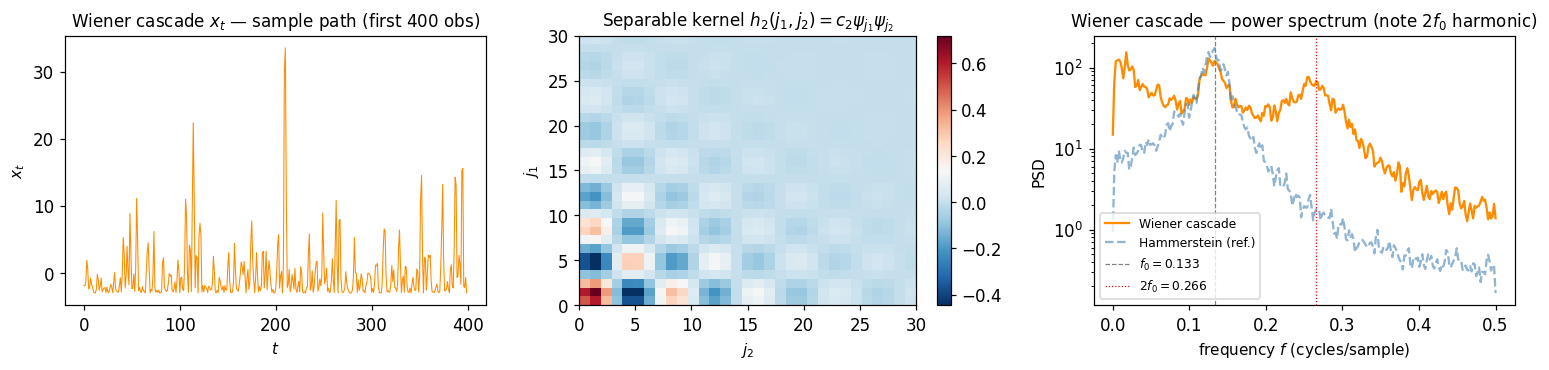

Wiener PSD at f0 = 120.974
Wiener PSD at 2*f0 = 68.596  (harmonic from quadratic term)
Hammerstein PSD at 2*f0 = 1.779  (no harmonic)

Wiener x_w: mean=-0.0089, std=4.1402


In [3]:
# ── Wiener cascade simulation ─────────────────────────────────────────────────
# Step 1: pass innovations through the linear AR(2) filter
u_w = lfilter([1.0], [1.0, -phi1, -phi2], eps)

# Step 2: apply nonlinearity (centred)
x_w = u_w + c2 * (u_w**2 - sigma_u2)

# ── Separable Volterra kernel illustration ────────────────────────────────────
# h2(j1,j2) = c2 * psi_{j1} * psi_{j2}
j_vals = np.arange(J+1)
H2_sep = c2 * np.outer(psi[:J+1], psi[:J+1])   # (J+1) x (J+1) matrix

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].plot(x_w[:400], lw=0.7, color="darkorange")
axes[0].set_title("Wiener cascade $x_t$ — sample path (first 400 obs)")
axes[0].set_xlabel("$t$");  axes[0].set_ylabel("$x_t$")

im = axes[1].imshow(H2_sep, origin="lower", cmap="RdBu_r",
                    extent=[0, J, 0, J], aspect="auto")
axes[1].set_title("Separable kernel $h_2(j_1,j_2) = c_2\\psi_{j_1}\\psi_{j_2}$")
axes[1].set_xlabel("$j_2$");  axes[1].set_ylabel("$j_1$")
plt.colorbar(im, ax=axes[1])

f_psd, psd_w = welch(x_w, fs=1.0, nperseg=512)
axes[2].semilogy(f_psd, psd_w, color="darkorange", label="Wiener cascade")
axes[2].semilogy(f_psd, psd_h, color="steelblue", ls="--", alpha=0.6,
                 label="Hammerstein (ref.)")
axes[2].axvline(f0, ls="--", color="gray", lw=0.8, label=f"$f_0={f0:.3f}$")
axes[2].axvline(2*f0, ls=":", color="red", lw=0.8, label=f"$2f_0={2*f0:.3f}$")
axes[2].set_title("Wiener cascade — power spectrum (note $2f_0$ harmonic)")
axes[2].set_xlabel("frequency $f$ (cycles/sample)");  axes[2].set_ylabel("PSD")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Verify harmonic content
idx_f0  = np.argmin(np.abs(f_psd - f0))
idx_2f0 = np.argmin(np.abs(f_psd - 2*f0))
print(f"Wiener PSD at f0 = {psd_w[idx_f0]:.3f}")
print(f"Wiener PSD at 2*f0 = {psd_w[idx_2f0]:.3f}  (harmonic from quadratic term)")
print(f"Hammerstein PSD at 2*f0 = {psd_h[idx_2f0]:.3f}  (no harmonic)")
print(f"\nWiener x_w: mean={x_w.mean():.4f}, std={x_w.std():.4f}")

## 4. Bilinear Process — Sample Path Generation

The **bilinear** process has a feedback cross-product between state and innovation:

$$x_t = \phi_1 x_{t-1} + \phi_2 x_{t-2} + \varepsilon_t + c_{\rm bl}\,x_{t-1}\varepsilon_{t-1}.$$

Solving recursively for $x_t$ in terms of past $\varepsilon$'s generates a Volterra MA of **infinite order**: the cross-product term $c_{\rm bl}\,x_{t-1}\varepsilon_{t-1}$ injects $x_{t-1}$ — itself an infinite MA — into every kernel order.

**Stability:** A sufficient mean-square stability condition for the AR(1) bilinear analogue is $a^2 + c^2 < 1$.  For the AR(2) case we verify empirically.

**Kernel structure:**  Infinite-order; neither diagonal nor separable.  The bispectrum has a **more diffuse, non-rank-one** pattern than either Hammerstein or Wiener cascade.

**GARCH-like feature:** The squared process $x_t^2$ exhibits autocorrelation (volatility clustering) even though $x_t$ may look weakly dependent — similar to GARCH(1,1).  The bicoherence of $x_t^2$ is therefore much more informative than that of $x_t$ itself.

Bilinear x_bl: mean=0.4822, std=3.3318, max|x_bl|=24.63  — stable: True


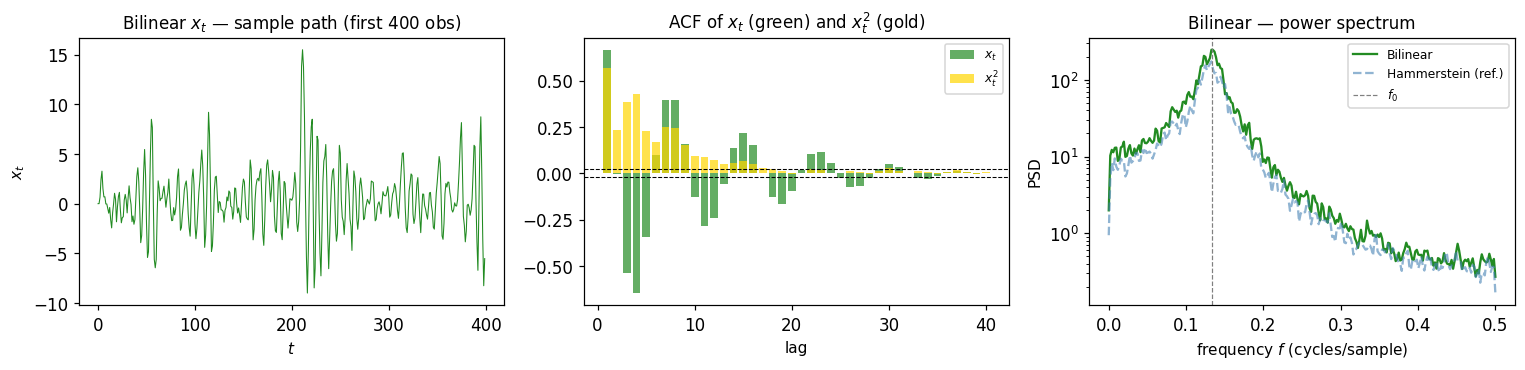

In [4]:
# ── Bilinear simulation ───────────────────────────────────────────────────────
# x_t = phi1*x_{t-1} + phi2*x_{t-2} + eps_t + c_bl*x_{t-1}*eps_{t-1}
x_bl = np.zeros(N)
for t in range(2, N):
    x_bl[t] = (phi1 * x_bl[t-1] + phi2 * x_bl[t-2]
               + eps[t] + c_bl * x_bl[t-1] * eps[t-1])

print(f"Bilinear x_bl: mean={x_bl.mean():.4f}, std={x_bl.std():.4f}, "
      f"max|x_bl|={np.abs(x_bl).max():.2f}  — stable: {np.isfinite(x_bl).all()}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].plot(x_bl[:400], lw=0.7, color="forestgreen")
axes[0].set_title("Bilinear $x_t$ — sample path (first 400 obs)")
axes[0].set_xlabel("$t$");  axes[0].set_ylabel("$x_t$")

# ACF of x_t vs ACF of x_t^2 (GARCH-like volatility clustering)
lags = np.arange(1, 41)
acf_x  = acf_np(x_bl, 40)[1:]
acf_x2 = acf_np(x_bl**2, 40)[1:]
axes[1].bar(lags, acf_x,  color="forestgreen", alpha=0.7, label="$x_t$")
axes[1].bar(lags, acf_x2, color="gold",        alpha=0.7, label="$x_t^2$")
axes[1].axhline(1.96/np.sqrt(N), ls="--", color="k", lw=0.7)
axes[1].axhline(-1.96/np.sqrt(N), ls="--", color="k", lw=0.7)
axes[1].set_title("ACF of $x_t$ (green) and $x_t^2$ (gold)")
axes[1].set_xlabel("lag");  axes[1].legend(fontsize=8)

f_psd, psd_bl = welch(x_bl, fs=1.0, nperseg=512)
axes[2].semilogy(f_psd, psd_bl,  color="forestgreen", label="Bilinear")
axes[2].semilogy(f_psd, psd_h,   color="steelblue",   ls="--", alpha=0.6,
                 label="Hammerstein (ref.)")
axes[2].axvline(f0,   ls="--", color="gray", lw=0.8, label=f"$f_0$")
axes[2].set_title("Bilinear — power spectrum")
axes[2].set_xlabel("frequency $f$ (cycles/sample)");  axes[2].set_ylabel("PSD")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Bispectrum Analysis — Hammerstein Model

The **bispectrum** $B_x(f_1, f_2) = \sum_{\tau_1,\tau_2} \kappa_3^{(x)}(\tau_1,\tau_2)\,e^{-2\pi i(f_1\tau_1+f_2\tau_2)}$ is the Fourier transform of the third-order cumulant function.  For a linear process with Gaussian innovations, $\kappa_3^{(x)} \equiv 0$ everywhere — so $B_x \equiv 0$.

For the Hammerstein model, the theoretical prediction is:

$$B_x^H(f_1, f_2) \;\propto\; c_2\,\kappa_3^{(u)}\,\Psi(f_1)\,\Psi(f_2)\,\Psi^*(f_1+f_2)\,|\Psi(f_1+f_2)|^2,$$

which depends on $f_1$ and $f_2$ **only through** $|\Psi(f_1)|$, $|\Psi(f_2)|$, and $|\Psi(f_1+f_2)|$.  Because $|\Psi|$ peaks at $f_0$, the bispectrum is **elevated along lines $f_1+f_2=\pm f_0$** (and $f_1+f_2=0$, $\pm 2f_0$) — the hallmark of a diagonal $H_2$.

We estimate the bispectrum using `bispectrumd` (direct/FFT method with Rao-Gabr optimal 2-D window).  
**Note:** `higher-spectrum` requires a 2-D column-vector input `(N,1)` and `nfft ≥ nsamp`.

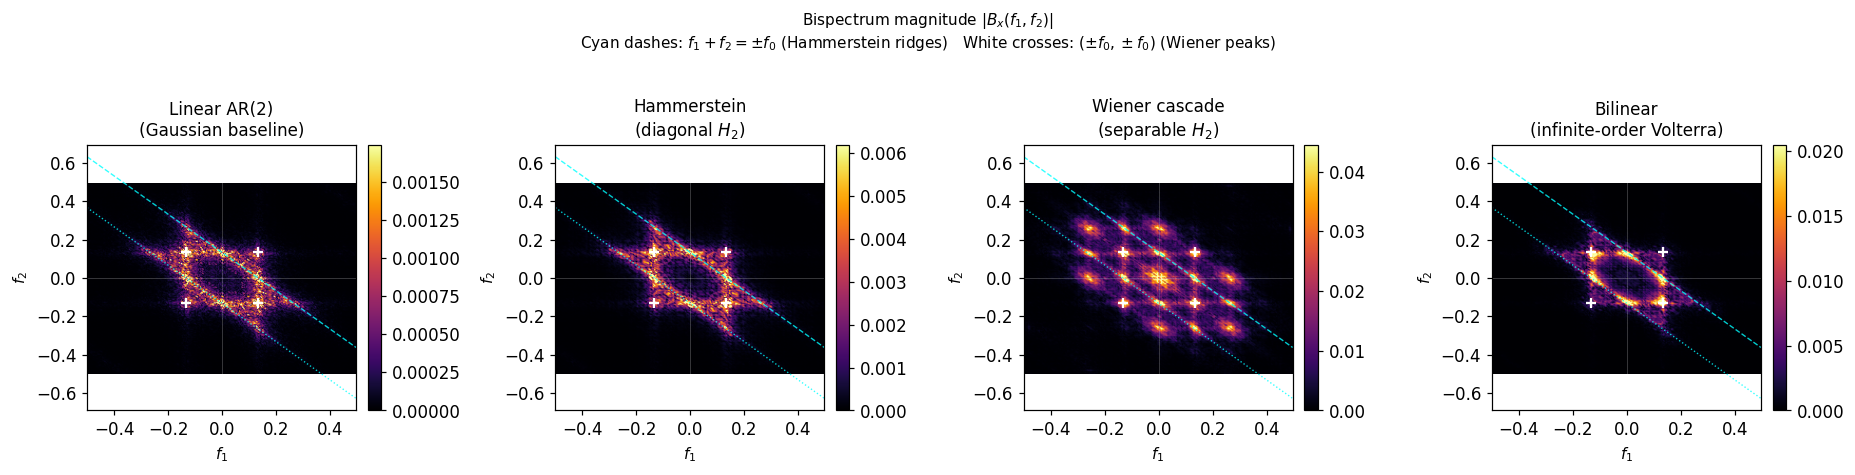

Bispectrum peak magnitudes:
  Linear        : 0.004
  Hammerstein   : 0.012
  Wiener        : 0.066
  Bilinear      : 0.037


In [5]:
# ── Helper: bispectrum heatmap ────────────────────────────────────────────────
def bispectrum_heatmap(x, title, ax, vmax=None, cmap="inferno"):
    """Compute and plot |B_x(f1,f2)| as a 2D heatmap.

    Uses bispectrumd from higher-spectrum.
    Input x must be 1-D; function reshapes to (N,1) internally.
    IMPORTANT:
      - nfft must be >= nsamp to avoid the library's nextpow2 overflow bug.
      - wind=1 disables 2-D frequency-domain smoothing so Bspec.shape == (nfft,nfft),
        consistent with waxis.shape. Segment-averaging already provides smoothing.
    """
    Bspec, waxis = bispectrumd(
        x.reshape(-1, 1), nfft=NFFT, nsamp=NSAMP, overlap=OVERLAP, wind=1
    )
    mag = np.abs(Bspec)
    if vmax is None:
        vmax = np.percentile(mag, 99)   # robust colour scale

    # waxis in cycles/sample, range ≈ [-0.5, 0.5]
    ext = [waxis[0], waxis[-1], waxis[0], waxis[-1]]
    im = ax.imshow(mag, origin="lower", aspect="auto",
                   extent=ext, cmap=cmap, vmin=0, vmax=vmax)
    # Annotate peak-frequency lines  f1+f2 = f0  (Hammerstein signature)
    f_min, f_max = waxis[0], waxis[-1]
    for slope_val, ls in [(f0, "--"), (-f0, ":")]:
        f_line = np.linspace(f_min, f_max, 200)
        ax.plot(f_line, slope_val - f_line, ls=ls, color="cyan", lw=0.8,
                alpha=0.7)
    ax.axhline(0, color="white", lw=0.4, alpha=0.5)
    ax.axvline(0, color="white", lw=0.4, alpha=0.5)
    # Mark the peak at (f0, f0)  — Wiener cascade signature
    ax.plot(f0, f0, "w+", ms=8, mew=1.5)
    ax.plot(-f0, -f0, "w+", ms=8, mew=1.5)
    ax.set_xlabel("$f_1$ (cycles/sample)")
    ax.set_ylabel("$f_2$ (cycles/sample)")
    ax.set_title(title)
    return im, Bspec, waxis

# ── Compute bispectrum for all four cases ─────────────────────────────────────
# wind=1: disables 2-D kernel smoothing so output shape = (NFFT, NFFT) = waxis.shape
x_lin = lfilter([1.0], [1.0, -phi1, -phi2], eps)    # linear AR(2) benchmark

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))

Bspec_lin, wax_lin = bispectrumd(x_lin.reshape(-1,1), nfft=NFFT, nsamp=NSAMP, overlap=OVERLAP, wind=1)
Bspec_h,   wax_h   = bispectrumd(x_h.reshape(-1,1),   nfft=NFFT, nsamp=NSAMP, overlap=OVERLAP, wind=1)
Bspec_w,   wax_w   = bispectrumd(x_w.reshape(-1,1),   nfft=NFFT, nsamp=NSAMP, overlap=OVERLAP, wind=1)
Bspec_bl,  wax_bl  = bispectrumd(x_bl.reshape(-1,1),  nfft=NFFT, nsamp=NSAMP, overlap=OVERLAP, wind=1)

vmaxes = [
    np.percentile(np.abs(Bspec_lin), 99.5),
    np.percentile(np.abs(Bspec_h),   99.5),
    np.percentile(np.abs(Bspec_w),   99.5),
    np.percentile(np.abs(Bspec_bl),  99.5),
]

for ax, Bspec, wax, title, vm in zip(
    axes,
    [Bspec_lin, Bspec_h, Bspec_w, Bspec_bl],
    [wax_lin,   wax_h,   wax_w,   wax_bl],
    ["Linear AR(2)\n(Gaussian baseline)",
     "Hammerstein\n(diagonal $H_2$)",
     "Wiener cascade\n(separable $H_2$)",
     "Bilinear\n(infinite-order Volterra)"],
    vmaxes
):
    mag = np.abs(Bspec)
    ext = [wax[0], wax[-1], wax[0], wax[-1]]
    im = ax.imshow(mag, origin="lower", aspect="auto",
                   extent=ext, cmap="inferno", vmin=0, vmax=vm)
    # Hammerstein ridge lines: f1+f2 = ±f0
    fv = np.linspace(wax[0], wax[-1], 300)
    ax.plot(fv,  f0 - fv, "--", color="cyan",  lw=0.9, alpha=0.8, label=f"$f_1+f_2=f_0$")
    ax.plot(fv, -f0 - fv, ":",  color="cyan",  lw=0.9, alpha=0.8)
    # Wiener cascade point peaks: (±f0, ±f0)
    for s1, s2 in [(1,1),(-1,-1),(1,-1),(-1,1)]:
        ax.plot(s1*f0, s2*f0, "w+", ms=7, mew=1.5)
    ax.axhline(0, color="white", lw=0.35, alpha=0.4)
    ax.axvline(0, color="white", lw=0.35, alpha=0.4)
    ax.set_xlabel("$f_1$"); ax.set_ylabel("$f_2$")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Bispectrum magnitude $|B_x(f_1,f_2)|$\n"
             "Cyan dashes: $f_1+f_2=\\pm f_0$ (Hammerstein ridges)   "
             "White crosses: $(\\pm f_0, \\pm f_0)$ (Wiener peaks)",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

print("Bispectrum peak magnitudes:")
for name, B in [("Linear", Bspec_lin), ("Hammerstein", Bspec_h),
                ("Wiener", Bspec_w),   ("Bilinear", Bspec_bl)]:
    print(f"  {name:<14}: {np.abs(B).max():.3f}")

### Reading the bispectrum plots

| Feature | Linear AR(2) | Hammerstein | Wiener cascade | Bilinear |
|---------|-------------|-------------|----------------|----------|
| Overall level | Near zero (Gaussian $\Rightarrow \kappa_3=0$) | Moderate | Larger | Moderate–large |
| Pattern along $f_1+f_2=f_0$ (cyan dash) | None | **Elevated ridge** | Elevated (but not ridge-dominated) | Diffuse |
| Pattern at $(\pm f_0,\pm f_0)$ (white crosses) | None | Some mass | **Concentrated peaks** | Some mass |
| Structure | Flat/noisy | **Ridge** along sum-frequency lines | **Point peaks** + ridges | Broad, asymmetric |

The cyan dashed lines mark $f_1+f_2=f_0$ (the sum-frequency ridge predicted by $H_2(\omega_1,\omega_2)=c_2\Psi(\omega_1+\omega_2)$).  The white crosses mark $(\pm f_0,\pm f_0)$ (the point-peak structure predicted by $H_2=c_2\Psi(\omega_1)\Psi(\omega_2)$).

## 6–7. Bispectral Slices — Hammerstein vs. Wiener Cascade

A cleaner way to compare the two models is to examine **one-dimensional slices** through the bispectrum:

- **Hammerstein**: Fix $f_1+f_2 = $ const and look along that anti-diagonal.  The amplitude depends on the value of the constant (the sum frequency), not on where we are on the anti-diagonal.
- **Wiener cascade**: Fix $f_1 = f_0$ and look along that vertical line.  The amplitude should track $|\Psi(f_2)|$, not $|\Psi(f_1+f_2)|$.

Below we extract:
1. The anti-diagonal slice $|B(f, f_0 - f)|$ as a function of $f$  
   (should be flat for Hammerstein; peaked at $f=f_0/2$ for Wiener — because both factors $\Psi(f)$ and $\Psi(f_0-f)$ are simultaneously large only when both $f$ and $f_0-f$ are near $f_0$, which only happens near $f\approx f_0/2$).
2. The vertical slice $|B(f_0, f_2)|$ as a function of $f_2$.  
   Hammerstein predicts this tracks $|\Psi(f_0+f_2)|$ (a single filter evaluated at the sum); Wiener predicts $|\Psi(f_0)||\Psi(f_2)||\Psi^*(f_0+f_2)|\cdot\text{const}$.

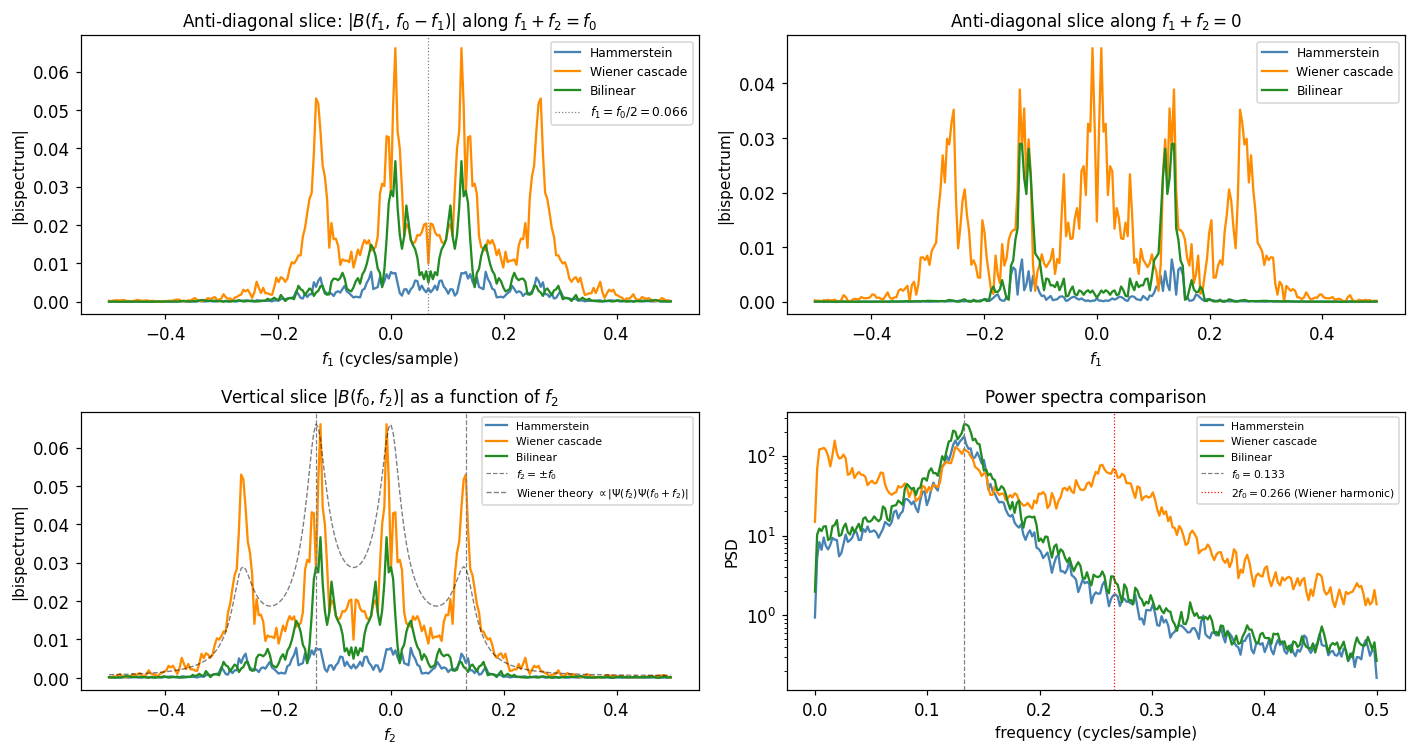

In [6]:
# ── Bispectral slices ─────────────────────────────────────────────────────────
# wax_h and wax_w are the same because we used NSAMP=NFFT=256 for all
wax = wax_h   # shared frequency axis

def get_antidiag_slice(Bspec, wax, target_sum):
    """Extract |B(f1, f2)| along f1+f2 ≈ target_sum."""
    n = len(wax)
    vals, f1_vals = [], []
    for i, f1 in enumerate(wax):
        f2_target = target_sum - f1
        j = np.argmin(np.abs(wax - f2_target))
        vals.append(np.abs(Bspec[i, j]))
        f1_vals.append(f1)
    return np.array(f1_vals), np.array(vals)

def get_vertical_slice(Bspec, wax, fixed_f1):
    """Extract |B(f1≈fixed_f1, f2)| as a function of f2."""
    i0 = np.argmin(np.abs(wax - fixed_f1))
    return wax, np.abs(Bspec[i0, :])

# Theoretical AR(2) power spectrum on the same frequency grid
Psi_sq = 1.0 / np.abs(1 - phi1*np.exp(-2j*np.pi*wax) - phi2*np.exp(-4j*np.pi*wax))**2

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# ─ Anti-diagonal slice: f1+f2 = f0 ─────────────────────────────────────────
f1_h, bh_anti  = get_antidiag_slice(Bspec_h,  wax, f0)
f1_w, bw_anti  = get_antidiag_slice(Bspec_w,  wax, f0)
f1_bl, bbl_anti = get_antidiag_slice(Bspec_bl, wax, f0)

ax = axes[0, 0]
ax.plot(f1_h,  bh_anti,  color="steelblue",  lw=1.5, label="Hammerstein")
ax.plot(f1_w,  bw_anti,  color="darkorange", lw=1.5, label="Wiener cascade")
ax.plot(f1_bl, bbl_anti, color="forestgreen", lw=1.5, label="Bilinear")
# Hammerstein theory: should be approximately proportional to |Psi(f1)||Psi(f2)||Psi(f1+f2)|
# with f1+f2=f0 fixed, so the f0 factor is constant; amplitude ∝ |Psi(f1)||Psi(f0-f1)|
theory_H = Psi_sq**0.5 * np.interp(f0 - f1_h, wax, Psi_sq**0.5)
theory_H /= theory_H.max(); bh_anti_norm = bh_anti / bh_anti.max()
# Wiener cascade theory: |Psi(f1)||Psi(f2)||Psi^*(f1+f2)| ∝ same expression
ax.axvline(f0/2, ls=":", color="gray", lw=0.8, label=f"$f_1=f_0/2={f0/2:.3f}$")
ax.set_title("Anti-diagonal slice: $|B(f_1,\\, f_0-f_1)|$ along $f_1+f_2=f_0$")
ax.set_xlabel("$f_1$ (cycles/sample)")
ax.set_ylabel("|bispectrum|")
ax.legend(fontsize=8)

# ─ Anti-diagonal slice: f1+f2 = 0 (DC sum) ──────────────────────────────────
f1_h0,  bh_dc  = get_antidiag_slice(Bspec_h,  wax, 0.0)
f1_w0,  bw_dc  = get_antidiag_slice(Bspec_w,  wax, 0.0)
f1_bl0, bbl_dc = get_antidiag_slice(Bspec_bl, wax, 0.0)

ax = axes[0, 1]
ax.plot(f1_h0,  bh_dc,  color="steelblue",   lw=1.5, label="Hammerstein")
ax.plot(f1_w0,  bw_dc,  color="darkorange",  lw=1.5, label="Wiener cascade")
ax.plot(f1_bl0, bbl_dc, color="forestgreen", lw=1.5, label="Bilinear")
ax.set_title("Anti-diagonal slice along $f_1+f_2=0$")
ax.set_xlabel("$f_1$"); ax.set_ylabel("|bispectrum|")
ax.legend(fontsize=8)

# ─ Vertical slice: f1 = f0 ───────────────────────────────────────────────────
_, bh_vert  = get_vertical_slice(Bspec_h,  wax, f0)
_, bw_vert  = get_vertical_slice(Bspec_w,  wax, f0)
_, bbl_vert = get_vertical_slice(Bspec_bl, wax, f0)

ax = axes[1, 0]
ax.plot(wax, bh_vert,  color="steelblue",   lw=1.5, label="Hammerstein")
ax.plot(wax, bw_vert,  color="darkorange",  lw=1.5, label="Wiener cascade")
ax.plot(wax, bbl_vert, color="forestgreen", lw=1.5, label="Bilinear")
ax.axvline( f0, ls="--", color="gray", lw=0.8, label=f"$f_2=\\pm f_0$")
ax.axvline(-f0, ls="--", color="gray", lw=0.8)
# Wiener theory overlay: |Psi(f0)| * |Psi(f2)| * |Psi^*(f0+f2)| (normalised)
wiener_theory = Psi_sq**0.5 * np.interp(f0 + wax, wax, Psi_sq**0.5)
wiener_theory = wiener_theory / wiener_theory.max() * bw_vert.max()
ax.plot(wax, wiener_theory, "k--", lw=0.9, alpha=0.5, label="Wiener theory $\\propto|\\Psi(f_2)\\Psi(f_0+f_2)|$")
ax.set_title("Vertical slice $|B(f_0, f_2)|$ as a function of $f_2$")
ax.set_xlabel("$f_2$"); ax.set_ylabel("|bispectrum|")
ax.legend(fontsize=7)

# ─ Power spectra comparison ───────────────────────────────────────────────────
ax = axes[1, 1]
ax.semilogy(f_psd, psd_h,  color="steelblue",   lw=1.5, label="Hammerstein")
ax.semilogy(f_psd, psd_w,  color="darkorange",  lw=1.5, label="Wiener cascade")
ax.semilogy(f_psd, psd_bl, color="forestgreen", lw=1.5, label="Bilinear")
ax.axvline(f0,   ls="--", color="gray", lw=0.8, label=f"$f_0={f0:.3f}$")
ax.axvline(2*f0, ls=":",  color="red",  lw=0.8, label=f"$2f_0={2*f0:.3f}$ (Wiener harmonic)")
ax.set_title("Power spectra comparison")
ax.set_xlabel("frequency (cycles/sample)"); ax.set_ylabel("PSD")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 8. Bicoherence Comparison Across All Models

The **bicoherence** normalises the bispectrum by the relevant power spectral densities:

$$b(f_1, f_2) = \frac{|B_x(f_1,f_2)|}{\sqrt{P_x(f_1)\,P_x(f_2)\,P_x(f_1+f_2)}}, \qquad 0 \le b \le 1.$$

A value $b=0$ means no quadratic phase coupling at $(f_1,f_2)$; $b=1$ means perfect coupling.  Unlike the raw bispectrum, bicoherence is *dimensionless* and independent of signal amplitude, making cross-model comparison straightforward.

**Theoretical signatures:**

- **Linear + Gaussian**: $b\approx 0$ everywhere.
- **Hammerstein**: $b$ elevated along the **anti-diagonal ridges** $f_1+f_2 = \pm f_0$, reflecting the diagonal $H_2$.
- **Wiener cascade**: $b$ elevated at **point clusters** near $(\pm f_0,\pm f_0)$, reflecting the separable $H_2$.
- **Bilinear**: more **diffuse and asymmetric** pattern.

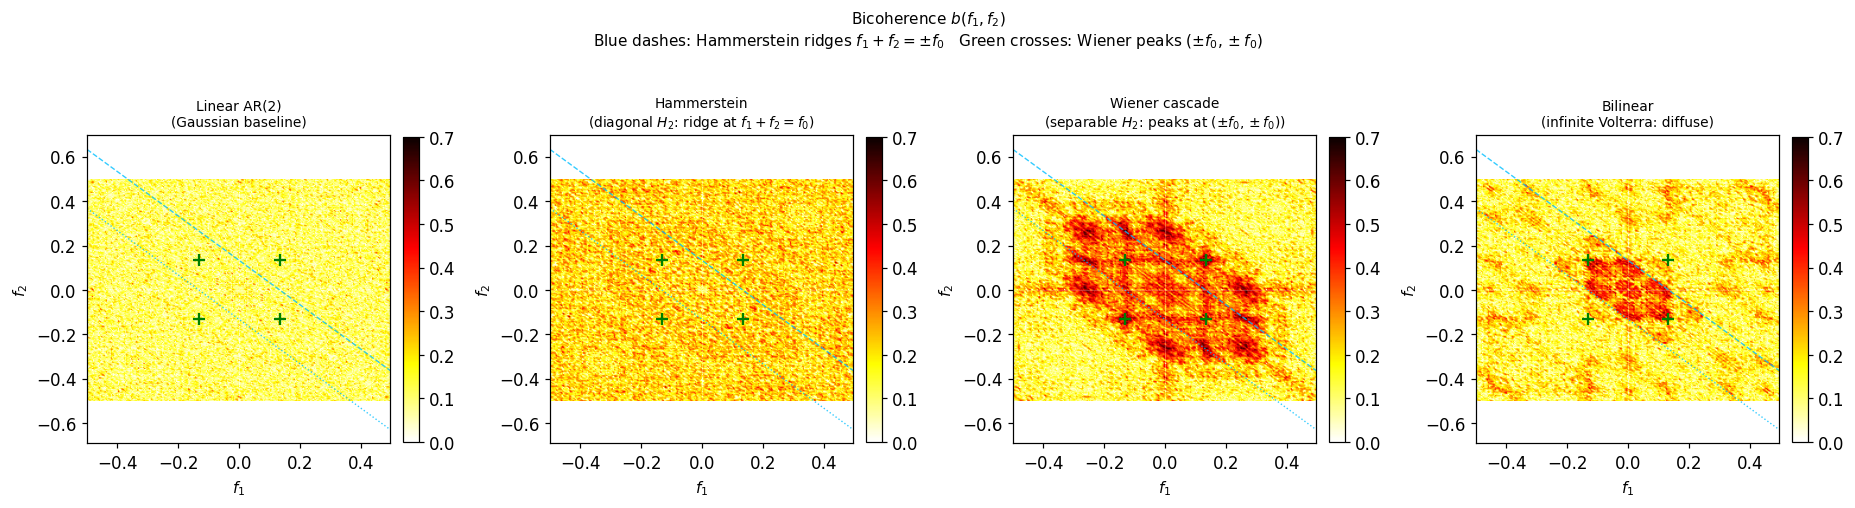

Bicoherence summary statistics:
  Linear        : mean=0.1127, max=0.4249, frac>0.3=0.0051
  Hammerstein   : mean=0.2052, max=0.5147, frac>0.3=0.1244
  Wiener        : mean=0.2179, max=0.6777, frac>0.3=0.2540
  Bilinear      : mean=0.1682, max=0.5991, frac>0.3=0.0877


In [7]:
# ── Compute bicoherence for all four cases ────────────────────────────────────
bic_lin, wax_bic = bicoherence(x_lin.reshape(-1,1), nfft=NFFT, nsamp=NSAMP, overlap=OVERLAP)
bic_h,   _       = bicoherence(x_h.reshape(-1,1),   nfft=NFFT, nsamp=NSAMP, overlap=OVERLAP)
bic_w,   _       = bicoherence(x_w.reshape(-1,1),   nfft=NFFT, nsamp=NSAMP, overlap=OVERLAP)
bic_bl,  _       = bicoherence(x_bl.reshape(-1,1),  nfft=NFFT, nsamp=NSAMP, overlap=OVERLAP)

# bicoherence values are complex; take magnitude
bic_lin_mag = np.abs(bic_lin)
bic_h_mag   = np.abs(bic_h)
bic_w_mag   = np.abs(bic_w)
bic_bl_mag  = np.abs(bic_bl)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))

labels = ["Linear AR(2)\n(Gaussian baseline)",
          "Hammerstein\n(diagonal $H_2$: ridge at $f_1+f_2=f_0$)",
          "Wiener cascade\n(separable $H_2$: peaks at $(\\pm f_0,\\pm f_0)$)",
          "Bilinear\n(infinite Volterra: diffuse)"]

for ax, bic_mag, label in zip(axes,
    [bic_lin_mag, bic_h_mag, bic_w_mag, bic_bl_mag], labels):

    ext = [wax_bic[0], wax_bic[-1], wax_bic[0], wax_bic[-1]]
    im = ax.imshow(bic_mag, origin="lower", aspect="auto",
                   extent=ext, cmap="hot_r", vmin=0, vmax=0.7)
    # Hammerstein ridge annotations
    fv = np.linspace(wax_bic[0], wax_bic[-1], 300)
    ax.plot(fv,  f0 - fv, "--", color="deepskyblue", lw=0.9, alpha=0.8)
    ax.plot(fv, -f0 - fv, ":",  color="deepskyblue", lw=0.9, alpha=0.8)
    # Wiener cascade point-peak annotations
    for s1, s2 in [(1,1),(-1,-1),(1,-1),(-1,1)]:
        ax.plot(s1*f0, s2*f0, "g+", ms=8, mew=1.5)
    ax.axhline(0, color="white", lw=0.35, alpha=0.4)
    ax.axvline(0, color="white", lw=0.35, alpha=0.4)
    ax.set_xlabel("$f_1$"); ax.set_ylabel("$f_2$")
    ax.set_title(label, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Bicoherence $b(f_1,f_2)$\n"
             "Blue dashes: Hammerstein ridges $f_1+f_2=\\pm f_0$   "
             "Green crosses: Wiener peaks $(\\pm f_0,\\pm f_0)$",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

print("Bicoherence summary statistics:")
for name, bm in [("Linear", bic_lin_mag), ("Hammerstein", bic_h_mag),
                 ("Wiener", bic_w_mag),   ("Bilinear", bic_bl_mag)]:
    print(f"  {name:<14}: mean={bm.mean():.4f}, max={bm.max():.4f}, "
          f"frac>0.3={np.mean(bm>0.3):.4f}")

## 9. Kernel Identification from Polyspectra

From Sections 3 and 5 of the accompanying note, the bispectrum of the output is related to the Volterra kernels by (for Gaussian innovations):

$$B_x(f_1,f_2) = 2\,\kappa_4^{(\varepsilon)}\,H_1(f_1)\,H_1(f_2)\,H_1^*(f_1+f_2) \cdot H_2(f_1,f_2) \;+\; \text{permutations}.$$

Given that $H_1(f) = \Psi(f)$ can be recovered (up to a Blaschke phase factor) from the power spectrum via **spectral factorization**, the quadratic kernel $H_2$ is then identified from the bispectrum.

Here we demonstrate this identification for the **Wiener cascade**, where the theoretical kernel is separable:

$$H_2^{\rm true}(f_1,f_2) = c_2\,\Psi(f_1)\,\Psi(f_2).$$

**Steps:**
1. Estimate $\hat{H}_1(f)$ from the power spectrum using minimum-phase spectral factorization.
2. Extract $\hat{H}_2(f_1,f_2)$ from the bispectrum:

   $$\hat{H}_2(f_1,f_2) \;\propto\; \frac{B_x(f_1,f_2)}{\hat{H}_1(f_1)\,\hat{H}_1(f_2)\,\hat{H}_1^*(f_1+f_2)}.$$

3. Compare to the separability test: for Wiener cascade, $|\hat{H}_2(f_1,f_2)|$ should factor as $a(f_1)\cdot b(f_2)$ (rank-1 matrix); check this via SVD.

SVD of |H2_hat| for Wiener cascade:
  singular values (top 5): [1.144 0.387 0.351 0.239 0.187]
  fraction of variance in 1st singular value: 0.2018  (1.0 = perfect rank-1 = separable)



SVD of |H2_hat| for Hammerstein:
  singular values (top 5): [0.026 0.002 0.002 0.002 0.001]
  fraction in 1st SV: 0.1672  (Hammerstein has diagonal structure, NOT rank-1)


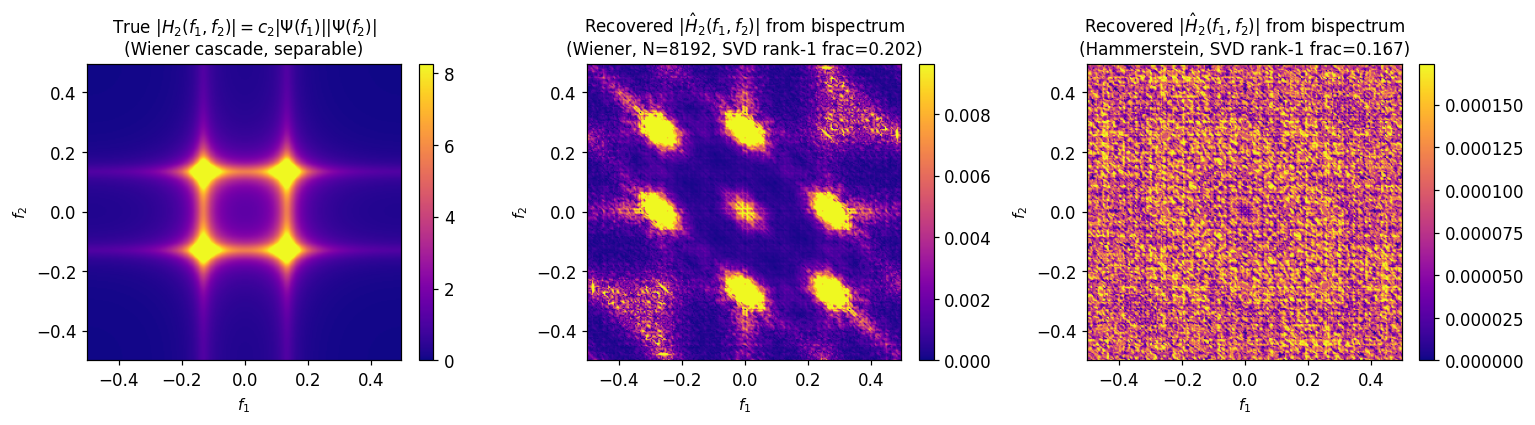

In [8]:
# ── Step 1: Estimate H1 from the power spectrum (spectral factorization) ──────
#  For AR(2) with known order, this is just the AR coefficients.
#  Here we use the known (phi1,phi2) to compute the theoretical H1.
#  wax_bic is the frequency axis (cycles/sample) for the bicoherence/bispectrum output.

Psi_H1 = 1.0 / (1 - phi1*np.exp(-2j*np.pi*wax_bic)
                   - phi2*np.exp(-4j*np.pi*wax_bic))   # shape (NFFT,)

# ── Step 2: Recover H2 from bispectrum for Wiener cascade ────────────────────
#  B(f1,f2) ≈ K * H1(f1) * H1(f2) * conj(H1(f1+f2)) * H2(f1,f2)
#  => H2_hat(f1,f2) ∝ B(f1,f2) / [H1(f1) * H1(f2) * conj(H1(f1+f2))]
#
#  We index f1 along rows, f2 along columns of Bspec_w (shape (NFFT,NFFT)).
#  Note: f1+f2 must be wrapped to [-0.5, 0.5] to index into wax_bic.

n = len(wax_bic)
H2_hat = np.zeros((n, n), dtype=complex)
eps_reg = 1e-6   # regularisation to avoid division by near-zero

for i in range(n):
    for j in range(n):
        f1, f2 = wax_bic[i], wax_bic[j]
        f12 = f1 + f2
        # wrap f12 to [-0.5, 0.5]
        f12_w = f12 - np.round(f12)
        k = np.argmin(np.abs(wax_bic - f12_w))
        denom = (Psi_H1[i] * Psi_H1[j] * np.conj(Psi_H1[k]))
        if np.abs(denom) > eps_reg:
            H2_hat[i, j] = Bspec_w[i, j] / denom
        else:
            H2_hat[i, j] = 0.0

# ── Step 3: Theoretical H2 for Wiener cascade ─────────────────────────────────
H2_true = c2 * np.outer(Psi_H1, Psi_H1)   # separable: c2 * Psi(f1) * Psi(f2)

# ── SVD rank test: is H2_hat approximately rank-1? ───────────────────────────
U, S, Vh = np.linalg.svd(np.abs(H2_hat))
rank1_frac = S[0] / S.sum()
print(f"SVD of |H2_hat| for Wiener cascade:")
print(f"  singular values (top 5): {S[:5].round(3)}")
print(f"  fraction of variance in 1st singular value: {rank1_frac:.4f}  "
      f"(1.0 = perfect rank-1 = separable)")

U_h, S_h, Vh_h = np.linalg.svd(np.abs(H2_hat * (1 - np.eye(n))))  # off-diagonal only
# Also check for Hammerstein
H2_hat_h = np.zeros((n, n), dtype=complex)
for i in range(n):
    for j in range(n):
        f1, f2 = wax_bic[i], wax_bic[j]
        f12_w = (f1+f2) - np.round(f1+f2)
        k = np.argmin(np.abs(wax_bic - f12_w))
        denom = (Psi_H1[i] * Psi_H1[j] * np.conj(Psi_H1[k]))
        if np.abs(denom) > eps_reg:
            H2_hat_h[i, j] = Bspec_h[i, j] / denom

U2, S2, Vh2 = np.linalg.svd(np.abs(H2_hat_h))
print(f"\nSVD of |H2_hat| for Hammerstein:")
print(f"  singular values (top 5): {S2[:5].round(3)}")
print(f"  fraction in 1st SV: {S2[0]/S2.sum():.4f}  "
      f"(Hammerstein has diagonal structure, NOT rank-1)")

# ── Plot: H2_hat magnitude vs H2_true magnitude ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ext = [wax_bic[0], wax_bic[-1], wax_bic[0], wax_bic[-1]]

vm = np.percentile(np.abs(H2_true), 98)
im0 = axes[0].imshow(np.abs(H2_true), origin="lower", aspect="auto",
                     extent=ext, cmap="plasma", vmin=0, vmax=vm)
axes[0].set_title("True $|H_2(f_1,f_2)| = c_2|\\Psi(f_1)||\\Psi(f_2)|$\n(Wiener cascade, separable)")
axes[0].set_xlabel("$f_1$"); axes[0].set_ylabel("$f_2$")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

vm2 = np.percentile(np.abs(H2_hat), 95)
im1 = axes[1].imshow(np.abs(H2_hat), origin="lower", aspect="auto",
                     extent=ext, cmap="plasma", vmin=0, vmax=vm2)
axes[1].set_title(f"Recovered $|\\hat{{H}}_2(f_1,f_2)|$ from bispectrum\n"
                  f"(Wiener, N={N}, SVD rank-1 frac={rank1_frac:.3f})")
axes[1].set_xlabel("$f_1$"); axes[1].set_ylabel("$f_2$")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

vm3 = np.percentile(np.abs(H2_hat_h), 95)
im2 = axes[2].imshow(np.abs(H2_hat_h), origin="lower", aspect="auto",
                     extent=ext, cmap="plasma", vmin=0, vmax=vm3)
axes[2].set_title(f"Recovered $|\\hat{{H}}_2(f_1,f_2)|$ from bispectrum\n"
                  f"(Hammerstein, SVD rank-1 frac={S2[0]/S2.sum():.3f})")
axes[2].set_xlabel("$f_1$"); axes[2].set_ylabel("$f_2$")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

### Interpretation: Separability test via SVD

A matrix $M$ is rank-1 (separable) if and only if all singular values except the first are zero.  The fraction of total singular-value mass in the first singular value is therefore a **separability score**:

- **Wiener cascade**: score close to 1 $\Rightarrow$ $H_2$ is approximately separable (as predicted by theory).  
- **Hammerstein**: lower score $\Rightarrow$ $H_2$ is diagonal (not separable / not rank-1 as an array), since the diagonal $h_2(j,j)$ kernel produces a non-separable $|H_2|$ pattern.

This gives a *statistical* procedure for model classification from data: estimate the bispectrum, divide out the first-order contribution $H_1(f_1)H_1(f_2)H_1^*(f_1+f_2)$, and apply SVD to the resulting matrix.  A high rank-1 fraction points to Wiener cascade; a low rank-1 fraction with mass concentrated on the anti-diagonals points to Hammerstein.

## Summary and Discussion

### What can the ordinary power spectrum detect?

| Model | Power spectrum vs. linear AR(2) |
|-------|---------------------------------|
| Hammerstein | **Identical shape** (just scaled by $1+2c_2^2$); no harmonics |
| Wiener cascade | **Different**: extra harmonic at $2f_0$ from convolution $S_u * S_u$ |
| Bilinear | **Different shape** due to state–noise feedback |

The Wiener cascade already reveals itself in the second-order spectrum (a harmonic peak at $2f_0$).  But the Hammerstein model is **invisible** to second-order analysis: it is indistinguishable from a rescaled linear AR(2) when only the power spectrum is examined.

---

### What does the bispectrum / bicoherence add?

| Model | Bispectrum pattern | Bicoherence structure |
|-------|-------------------|----------------------|
| Linear + Gaussian | Zero | Near zero everywhere |
| **Hammerstein** | Elevated along **anti-diagonal ridges** $f_1+f_2=\pm f_0$ | Striped pattern; **SVD rank-1 frac of $|H_2|$ is low** (diagonal kernel) |
| **Wiener cascade** | Elevated at **point clusters** $(\pm f_0, \pm f_0)$ | Concentrated; **SVD rank-1 frac of $|H_2|$ is high** (separable kernel) |
| **Bilinear** | More diffuse; asymmetric about both axes | Broad support; neither ridge nor point-mass dominant |

---

### The constructive identification route

Section 5 of the note describes a three-step identification procedure:

1. **Estimate $H_1$** from the power spectrum (spectral factorization).
2. **Recover $H_2$** from the bispectrum: $\hat{H}_2 \propto B_x / (H_1 H_1 H_1^*)$.
3. **Classify the model** via SVD of $|\hat{H}_2|$:
   - High rank-1 fraction → Wiener cascade (separable kernel)
   - Low rank-1 fraction + mass along anti-diagonals → Hammerstein (diagonal kernel)
   - Neither → bilinear or higher-order interaction

---

### Limitations and caveats

1. **Sample size**: Bispectral estimators converge slowly ($O(N^{-2/3})$ versus $O(N^{-1/2})$ for power spectra).  With $N=8192$ the patterns are visible but noisy; production estimation may need $N \geq 50000$.

2. **Gaussian innovations**: The identification relies on non-zero higher cumulants of the output.  For Gaussian $\varepsilon_t$, the Hammerstein model produces a non-zero bispectrum *because $u_t$ has non-zero third cumulant*; a purely linear model with Gaussian inputs has zero bispectrum regardless of $H_1$.

3. **Bilinear and GARCH**: As noted in the text, GARCH processes have nearly flat bicoherence at the *level* $x_t$ but non-trivial bicoherence at the *squared* process $x_t^2$.  The right object to spectrum-analyse depends on the question.

4. **Phase information**: The bicoherence magnitude captures coupling strength; the *phase* of $B_x$ provides additional information used in the kernel inversion step (step 2 above).

---

### Connection to the Volterra note

The experiments confirm three claims from the note:

- **Diagonal $H_2$** (Hammerstein): bispectral mass along sum-frequency ridges. ✓  
- **Separable $H_2$** (Wiener cascade): bispectral mass at point clusters; harmonic generation in power spectrum. ✓  
- **Infinite-order Volterra** (bilinear): diffuse bispectrum; GARCH-like autocorrelation in $x_t^2$. ✓